# **Malaria Detection**

## **Problem Definition**

### The Context — Why is this problem important?

Malaria is a major global health problem, especially in regions where access to trained diagnostic experts is limited. Diagnosis often relies on microscopy of stained blood-smear images. This can be accurate, but it is time-consuming and depends heavily on the skill and availability of trained technicians.

A computer vision model could help by quickly screening blood-cell images and flagging cells that are likely to be parasitized. This would not replace clinical judgment, but it could support faster and more consistent diagnosis, especially in high-volume or resource-limited settings.

### The Objective — What is the goal?

The goal is to build an image-classification model that can distinguish between:

- **Parasitized cells**: red blood cells infected with *Plasmodium*
- **Uninfected cells**: red blood cells without visible parasites

The model should perform well overall, but for this problem, it is especially important to minimize missed infections.

### Key Questions

1. Are the images and labels correctly loaded and prepared for modeling?
2. Is the dataset balanced between parasitized and uninfected cells?
3. Can a CNN learn visual patterns that separate the two classes?
4. Which model performs best on the held-out test set?
5. Which metric should guide the final model choice?

### Problem Formulation

This is a binary image-classification problem for malaria screening. The model takes 64×64 color images of individual cells and predicts whether each cell is uninfected or parasitized. Because this is a medical screening task, the most important goal is to avoid missing infected cells. For that reason, parasitized recall is treated as the main evaluation metric, while accuracy and F1 score are used as supporting metrics. Different models, including a baseline CNN, deeper CNNs, models with normalization and activation changes, data augmentation, and VGG16 transfer learning, are compared to identify the most suitable approach.

###<b> Mount the Drive

In [2]:
# Mount Google Drive so the dataset zip file can be accessed in Colab.

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


### <b>Loading libraries</b>

In [3]:
# Import libraries for file handling, data analysis, plotting, image processing, and modeling.

import os
import zipfile
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
import cv2

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

import tensorflow as tf
from tensorflow.keras import backend, optimizers, Model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Flatten, Dropout,
    BatchNormalization, LeakyReLU
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input

warnings.filterwarnings('ignore')

SEED = 42
IMAGE_SIZE = 64
CLASS_NAMES = ['Uninfected', 'Parasitized']
CLASS_TO_LABEL = {'uninfected': 0, 'parasitized': 1}
LABEL_TO_CLASS = {v: k.title() for k, v in CLASS_TO_LABEL.items()}


def reset_seeds(seed=SEED):
    """Reset random seeds so model runs are as reproducible as possible."""
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)


reset_seeds(SEED)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
sns.set_context('notebook')


### <b>Let us load the data</b>

**Note:**
- You must download the dataset from the link provided on Olympus and upload the same to your Google Drive. Then unzip the folder.

In [4]:
# ============================================================
# LOAD AND EXTRACT DATASET
# ============================================================
# This block extracts the dataset if needed and loads train/test images into arrays.

DATASET_ZIP_PATH = '/content/drive/MyDrive/Python_Course/cell_images.zip'
EXTRACT_DIR = '/content'
DATA_DIR = os.path.join(EXTRACT_DIR, 'cell_images')

if not os.path.exists(DATA_DIR):
    with zipfile.ZipFile(DATASET_ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)


def load_image_split(split_name, data_dir=DATA_DIR, image_size=IMAGE_SIZE):
    """Load one image split from split/class_name/image_file folders."""
    images = []
    labels = []
    skipped = 0

    split_dir = os.path.join(data_dir, split_name)

    for class_name, label in CLASS_TO_LABEL.items():
        class_dir = os.path.join(split_dir, class_name)
        image_files = sorted(os.listdir(class_dir))
        print(f'{split_name}/{class_name}: {len(image_files)} files found')

        for image_name in image_files:
            image_path = os.path.join(class_dir, image_name)

            try:
                image = Image.open(image_path).convert('RGB')
                image = image.resize((image_size, image_size))
                images.append(np.asarray(image))
                labels.append(label)
            except Exception:
                skipped += 1
                continue

    images = np.asarray(images)
    labels = np.asarray(labels, dtype='int32')

    print(f'Loaded {split_name}: {images.shape[0]} images | skipped: {skipped}')
    return images, labels


train_images, train_labels = load_image_split('train')
test_images, test_labels = load_image_split('test')

# Keep integer labels for EDA and metric calculations.
train_labels_int = train_labels.copy()
test_labels_int = test_labels.copy()

print('\nTraining Images Shape:', train_images.shape)
print('Training Labels Shape:', train_labels.shape)
print('Test Images Shape:', test_images.shape)
print('Test Labels Shape:', test_labels.shape)


train/uninfected: 12376 files found
train/parasitized: 12582 files found
Loaded train: 24958 images | skipped: 0
test/uninfected: 1300 files found
test/parasitized: 1300 files found
Loaded test: 2600 images | skipped: 0

Training Images Shape: (24958, 64, 64, 3)
Training Labels Shape: (24958,)
Test Images Shape: (2600, 64, 64, 3)
Test Labels Shape: (2600,)


The dataset is organized into separate train and test folders. Each split contains two class folders: **parasitized** and **uninfected**.

Before modeling, all images need to be resized to the same dimensions and stored as 4D arrays with the shape:

`number of images × height × width × color channels`

The labels are also created from the folder names so the model can learn which images belong to each class.

**About the dataset.** This dataset contains microscopic images of individual red blood cells labeled as either parasitized or uninfected. The images are already divided into training and test sets, allowing the model to learn from one set of images and then be evaluated on a separate held-out set. Since the goal is to identify infected cells from image patterns, this dataset is appropriate for a supervised image-classification approach.


In [5]:
# Summarize the number of images in each class for train and test sets.
class_count_summary = pd.DataFrame({
    'Train': pd.Series(train_labels_int).value_counts().sort_index(),
    'Test': pd.Series(test_labels_int).value_counts().sort_index()
})
class_count_summary.index = [LABEL_TO_CLASS[i] for i in class_count_summary.index]
class_count_summary


,Train,Test
Uninfected,12376,1300
Parasitized,12582,1300


###<b> Check the shape of train and test images

In [6]:
# Check that image arrays have the expected 4D shape.
print('Train images shape:', train_images.shape)
print('Test images shape :', test_images.shape)


Train images shape: (24958, 64, 64, 3)
Test images shape : (2600, 64, 64, 3)


###<b> Check the shape of train and test labels

In [7]:
# Check that labels are stored as 1D integer arrays before one-hot encoding.
print('Train labels shape:', train_labels_int.shape)
print('Test labels shape :', test_labels_int.shape)


Train labels shape: (24958,)
Test labels shape : (2600,)


#### Observations and insights

 The training and test images are stored as 4D arrays with shape `(number of images, 64, 64, 3)`. This means each image is 64×64 pixels with 3 color channels, which matches the input format expected by a Keras `Conv2D` layer. The training set is much larger than the test set, giving the model enough examples to learn from while keeping a separate test set for final evaluation. At this stage, the labels are stored as integer values, with `0` for uninfected and `1` for parasitized. These labels will be one-hot encoded before training so they work correctly with the model’s 2-unit softmax output.



### <b>Check the minimum and maximum range of pixel values for train and test images

In [8]:
# Check the pixel range before normalization.
print('Train pixel range:', train_images.min(), 'to', train_images.max())
print('Test pixel range :', test_images.min(), 'to', test_images.max())


Train pixel range: 0 to 255
Test pixel range : 0 to 255


#### Observations and insights

Pixel values range from 0 to 255, which is the standard range for RGB images. Before training, these values are scaled to fall between 0 and 1. This helps the model train more smoothly and efficiently because the input values are smaller and easier for the optimizer to work with.


###<b> Count the number of values in both uninfected and parasitized

In [9]:
# Display class counts before modeling.
print('Training set class counts:')
print(pd.Series(train_labels_int).map(LABEL_TO_CLASS).value_counts())

print('\nTest set class counts:')
print(pd.Series(test_labels_int).map(LABEL_TO_CLASS).value_counts())


Training set class counts:
Parasitized    12582
Uninfected     12376
Name: count, dtype: int64

Test set class counts:
Uninfected     1300
Parasitized    1300
Name: count, dtype: int64


###<b>Normalize the images

In [10]:
# Scale pixel values from 0-255 to 0-1 for more stable CNN training.
# This improves numerical stability and is the standard preprocessing step for CNNs.
train_images = (train_images / 255.0).astype('float32')
test_images = (test_images / 255.0).astype('float32')

print('Train pixel range after normalization:', train_images.min(), 'to', train_images.max())
print('Test pixel range after normalization :', test_images.min(), 'to', test_images.max())


Train pixel range after normalization: 0.0 to 1.0
Test pixel range after normalization : 0.0 to 1.0


#### Observations and insights

- After dividing by 255.0 and casting to `float32`, all pixel values now lie in the **[0, 1]** range expected by the network. `float32` is the default Keras dtype and uses half the memory of `float64`, which matters for a ~25K-image tensor.

###<b> Plot to check if the data is balanced

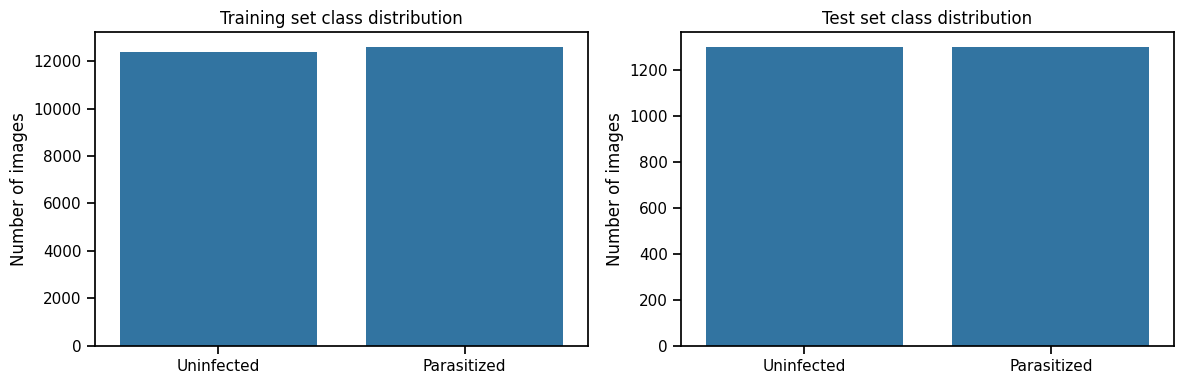

In [11]:
# Plot class counts for the train and test sets.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x=train_labels_int, ax=axes[0])
axes[0].set_title('Training set class distribution')
axes[0].set_xticklabels(CLASS_NAMES)
axes[0].set_ylabel('Number of images')

sns.countplot(x=test_labels_int, ax=axes[1])
axes[1].set_title('Test set class distribution')
axes[1].set_xticklabels(CLASS_NAMES)
axes[1].set_ylabel('Number of images')

plt.tight_layout()
plt.show()


#### Observations and insights

- The dataset is **balanced** — roughly 50/50 parasitized vs. uninfected in both splits.
- Two implications follow: accuracy is a meaningful metric (it cannot be inflated by always predicting one class), and class-weighting or oversampling is unnecessary.
- However, accuracy is not the right metric to *optimize* for. In a clinical screening setting, a missed infection is far costlier than a false alarm, so **recall on the parasitized class** is the headline metric, with precision and F1 alongside.


### <b>Data Exploration</b>
Let's visualize the images from the train data

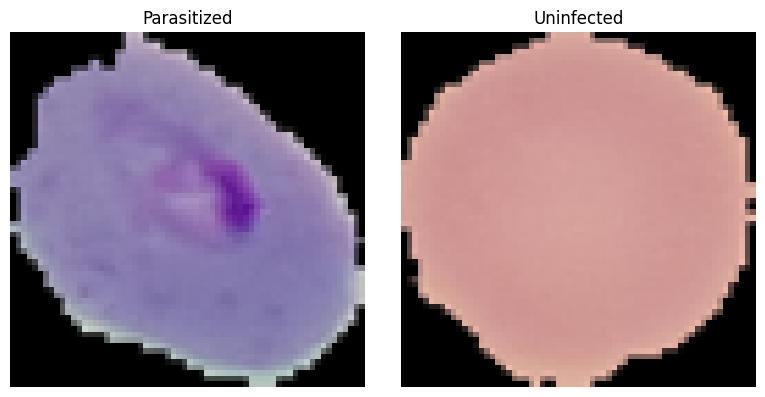

In [12]:
# Display one random parasitized cell and one random uninfected cell.
reset_seeds(SEED)

parasitized_idx = np.random.choice(np.where(train_labels_int == 1)[0])
uninfected_idx = np.random.choice(np.where(train_labels_int == 0)[0])

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(train_images[parasitized_idx])
axes[0].set_title('Parasitized')
axes[0].axis('off')

axes[1].imshow(train_images[uninfected_idx])
axes[1].set_title('Uninfected')
axes[1].axis('off')

plt.tight_layout()
plt.show()


#### Observations and insights

- Parasitized cells often show darker purple internal structures, while uninfected cells look more uniform.
- Some images include staining variation, debris, or edge artifacts, so the task is not perfectly simple.
- These visual differences support the use of CNNs, which can learn patterns in color, texture, and shape.


###<b> Visualize the images with subplot(6, 6) and figsize = (12, 12)

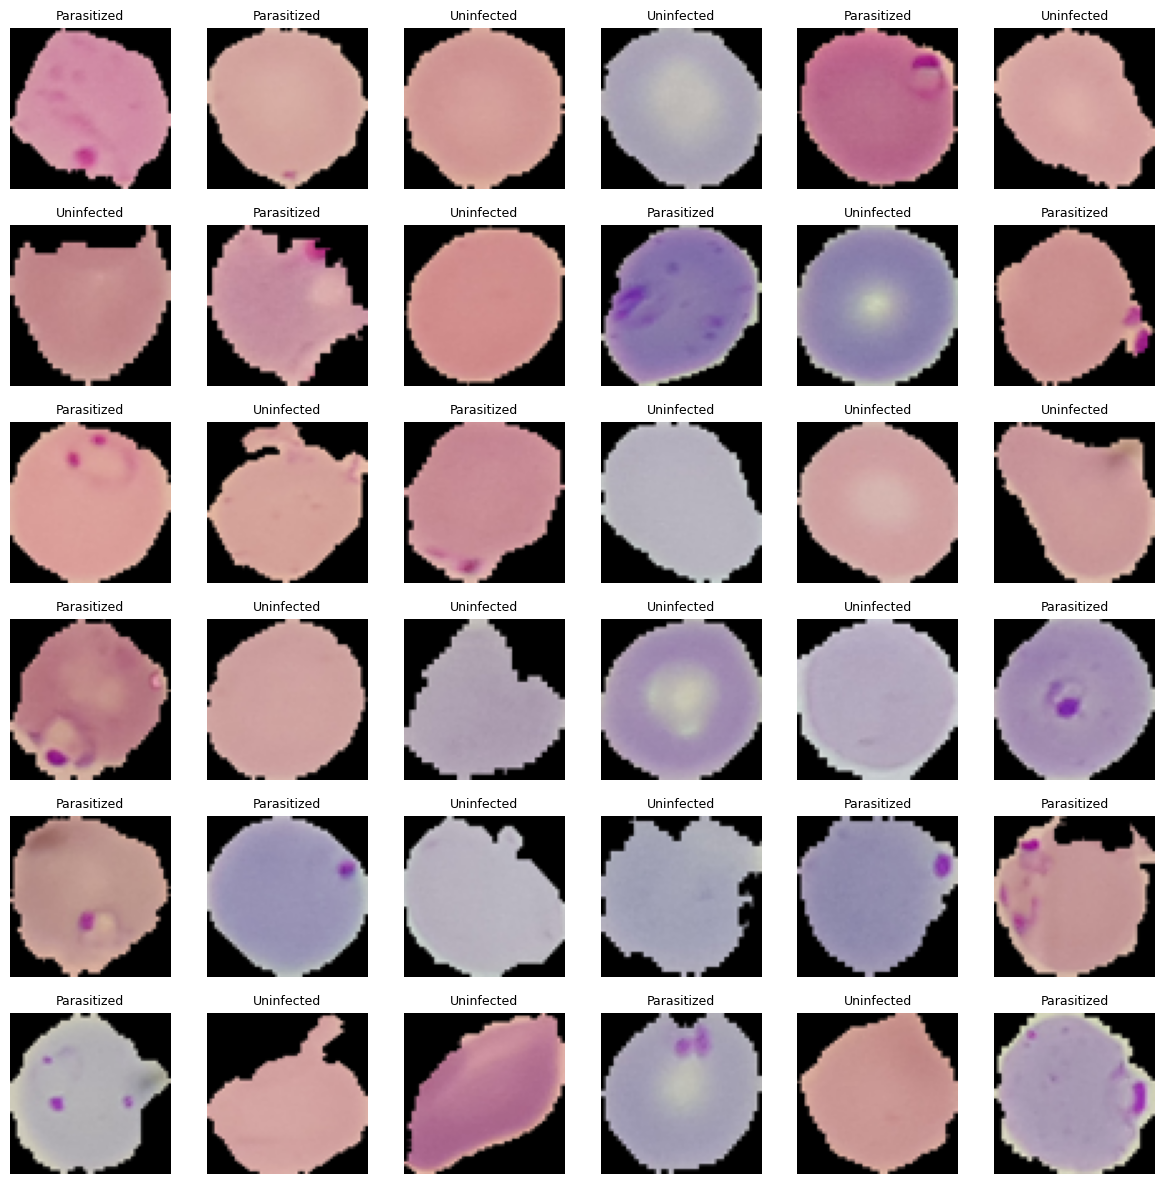

In [13]:
# Show random training images to inspect visual differences between classes.
reset_seeds(SEED)

plt.figure(figsize=(12, 12))
for n in range(1, 37):
    plt.subplot(6, 6, n)
    index = np.random.randint(0, train_images.shape[0])
    title = 'Parasitized' if train_labels_int[index] == 1 else 'Uninfected'
    plt.title(title, fontsize=9)
    plt.imshow(train_images[index])
    plt.axis('off')
plt.tight_layout()
plt.show()


#### Observations and insights

- Across 36 random samples, parasitized cells consistently display dark purple inclusions of varying size and shape, while uninfected cells are largely uniform.
- Some uninfected cells contain mild artifacts — stain debris, edge artifacts, or background colour variation — that could plausibly fool a weak classifier into a false positive.
- The dataset's visual diversity (orientation, exact stain hue, cell size) is wide enough that data augmentation should help; a model that only sees these specific examples may not generalize to a new microscopy setup.

- These visual differences support the problem formulation as a binary image-classification task: the model can learn image-based patterns, such as stain intensity, cell texture, and parasite-like inclusions, to separate parasitized from uninfected cells.


###<b> Plotting the mean images for parasitized and uninfected

In [14]:
# Calculate and display the average image for one class.
def plot_mean_image(images, labels, class_value, title):
    mean_img = images[labels == class_value].mean(axis=0)
    plt.figure(figsize=(4, 4))
    plt.imshow(mean_img)
    plt.title(f'Average {title}')
    plt.axis('off')
    plt.show()
    return mean_img


<b> Mean image for parasitized

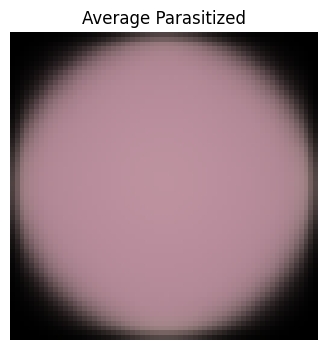

In [15]:
parasitized_mean = plot_mean_image(
    train_images, train_labels_int, class_value=1, title='Parasitized'
)


<b> Mean image for uninfected

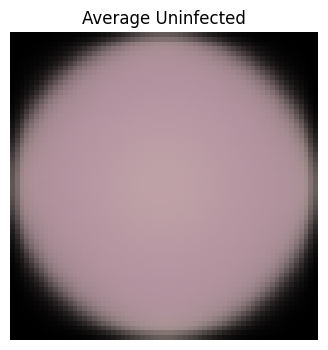

In [16]:
uninfected_mean = plot_mean_image(
    train_images, train_labels_int, class_value=0, title='Uninfected'
)


#### Observations and insights

- The mean parasitized image appears darker and more textured than the mean uninfected image.
- The mean uninfected image is smoother and more uniform.
- This suggests that the two classes have consistent visual differences that a CNN can learn.


### <b>Converting RGB to HSV of Images using OpenCV

###<b> Converting the train data

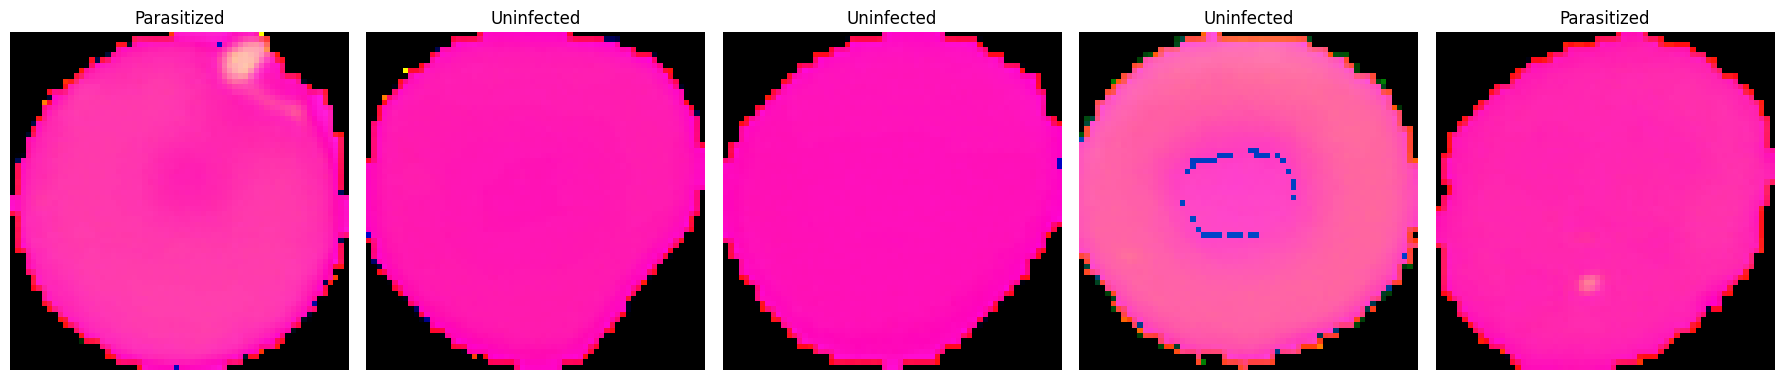

In [17]:
# Convert a small training-image sample from RGB to HSV for visual inspection.
# PIL loads images as RGB, so use cv2.COLOR_RGB2HSV rather than BGR2HSV.
reset_seeds(SEED)
sample_idx = np.random.choice(train_images.shape[0], size=5, replace=False)

fig, ax = plt.subplots(1, 5, figsize=(18, 4))
for t, i in enumerate(sample_idx):
    hsv_image = cv2.cvtColor(train_images[i], cv2.COLOR_RGB2HSV)
    title = 'Parasitized' if train_labels_int[i] == 1 else 'Uninfected'
    ax[t].set_title(title)
    ax[t].imshow(hsv_image)
    ax[t].set_axis_off()
plt.tight_layout()
plt.show()


###<b> Converting the test data

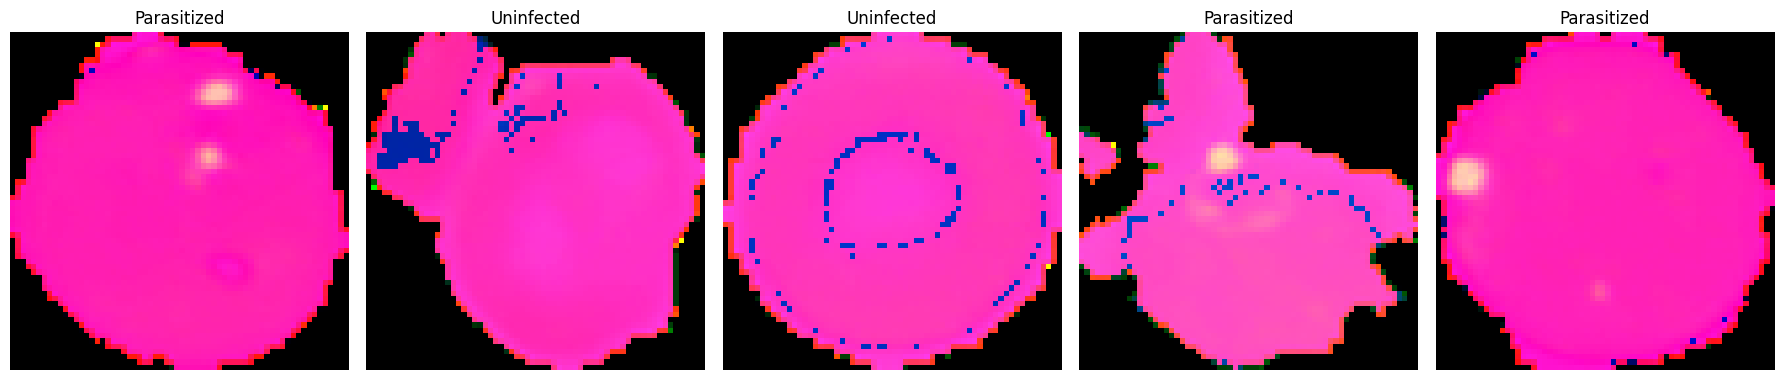

In [18]:
# Repeat the RGB-to-HSV check on test images.
reset_seeds(SEED)
sample_idx = np.random.choice(test_images.shape[0], size=5, replace=False)

fig, ax = plt.subplots(1, 5, figsize=(18, 4))
for t, i in enumerate(sample_idx):
    hsv_image = cv2.cvtColor(test_images[i], cv2.COLOR_RGB2HSV)
    title = 'Parasitized' if test_labels_int[i] == 1 else 'Uninfected'
    ax[t].set_title(title)
    ax[t].imshow(hsv_image)
    ax[t].set_axis_off()
plt.tight_layout()
plt.show()


#### Observations and insights

- The HSV colour space separates **hue** (which colour), **saturation** (how vivid), and **value** (how bright) into independent channels. RGB mixes all three.
- For this problem, HSV can highlight the parasite's distinctive pigmentation, which differs in hue and saturation from the surrounding cytoplasm.
- However, a CNN trained directly on RGB can learn an equivalent transformation from data — early conv filters routinely recover colour-channel combinations that act like saturation or hue detectors. So HSV is more useful as a manual preprocessing step for classical methods than as a substitute for learned deep features. We will keep RGB as the primary input.

###<b> Processing Images using Gaussian Blurring

###<b> Gaussian Blurring on train data

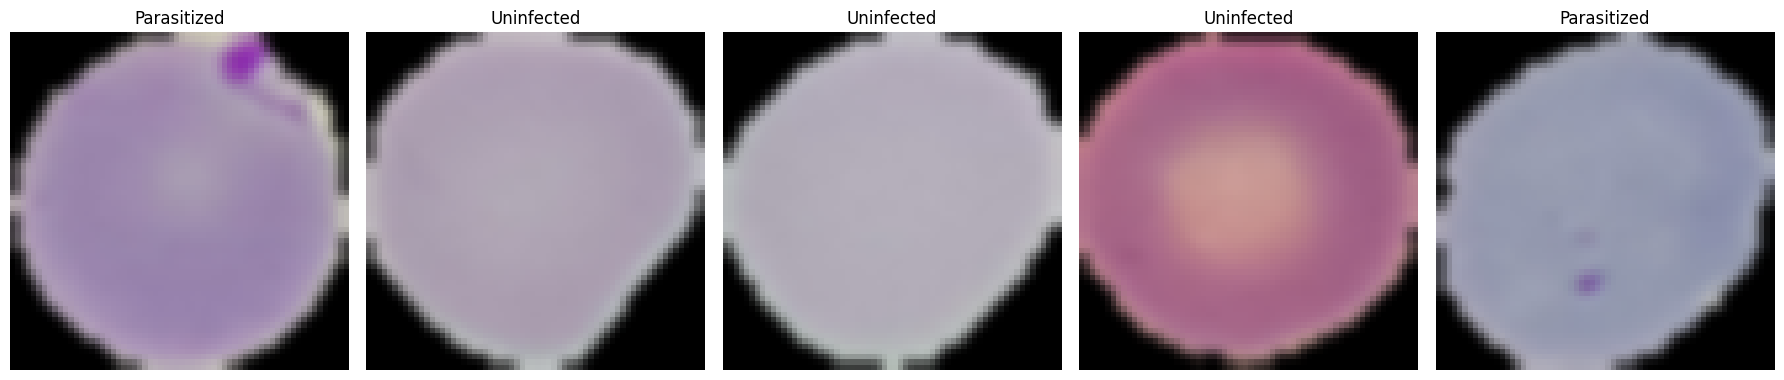

In [19]:
# Apply Gaussian blur to a small training-image sample.
reset_seeds(SEED)
sample_idx = np.random.choice(train_images.shape[0], size=5, replace=False)

fig, ax = plt.subplots(1, 5, figsize=(18, 4))
for t, i in enumerate(sample_idx):
    blurred_image = cv2.GaussianBlur(train_images[i], (5, 5), 0)
    title = 'Parasitized' if train_labels_int[i] == 1 else 'Uninfected'
    ax[t].set_title(title)
    ax[t].imshow(blurred_image)
    ax[t].set_axis_off()
plt.tight_layout()
plt.show()


###<b> Gaussian Blurring on test data

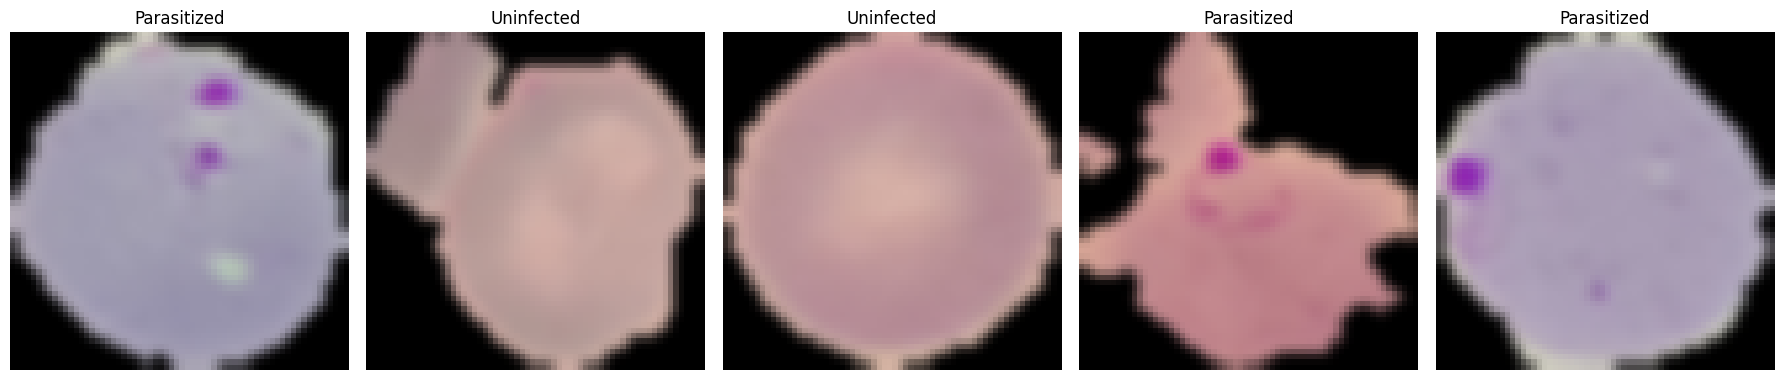

In [20]:
# Repeat the Gaussian blur check on test images.
reset_seeds(SEED)
sample_idx = np.random.choice(test_images.shape[0], size=5, replace=False)

fig, ax = plt.subplots(1, 5, figsize=(18, 4))
for t, i in enumerate(sample_idx):
    blurred_image = cv2.GaussianBlur(test_images[i], (5, 5), 0)
    title = 'Parasitized' if test_labels_int[i] == 1 else 'Uninfected'
    ax[t].set_title(title)
    ax[t].imshow(blurred_image)
    ax[t].set_axis_off()
plt.tight_layout()
plt.show()



**Observations and insights**

A Gaussian blur smooths the image and reduces small details or noise. However, in this project, the parasite may appear as a small, localized pattern inside the cell. If we blur the images too much, we may remove some of the very features the model needs to detect.

Because the images have already been resized to 64×64, they are already fairly low-resolution. Adding more smoothing may reduce useful detail rather than improve the model. For this reason, we will use the original, unblurred RGB images as input.

**Think About It:**
Blurring is probably not the best preprocessing choice for this task. Better options may include contrast enhancement methods or, more importantly, allowing the CNN to learn useful image features directly from the data, supported by data augmentation.

**Preprocessing summary.** Based on the preprocessing checks, the final modeling input will use normalized RGB images. Normalization is necessary for stable CNN training, while HSV conversion and Gaussian blurring are useful exploratory checks but are not used as final inputs — the CNN can learn color and texture features directly from RGB images, and blurring may remove small parasite-related details.


## **Model Building**

### **Base Model**




###<b> Importing the required libraries for building and training our Model

In [21]:
# Clear the Keras backend and define helper functions for callbacks, plots, and metrics.
backend.clear_session()
reset_seeds(SEED)


def make_callbacks(model_name, patience=3):
    """Create callbacks that prevent overfitting and restore the best validation-loss weights."""
    return [
        EarlyStopping(
            monitor='val_loss',
            patience=patience,
            restore_best_weights=True,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=f'best_{model_name}.keras',
            monitor='val_loss',
            save_best_only=True,
            verbose=0
        )
    ]


def plot_accuracy(history, title='Accuracy vs Epoch'):
    """Plot train and validation accuracy curves for one fitted Keras model."""
    plt.figure(figsize=(7, 5))
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def get_integer_labels(y):
    """Convert one-hot labels to integer labels if needed."""
    y = np.asarray(y)
    return np.argmax(y, axis=1) if y.ndim == 2 else y.astype('int32')


def predict_classes(model, X):
    """Return predicted class labels from either sigmoid or softmax Keras outputs."""
    y_pred_prob = model.predict(X, verbose=0)
    if y_pred_prob.ndim == 1 or y_pred_prob.shape[-1] == 1:
        return (y_pred_prob.ravel() >= 0.5).astype('int32')
    return np.argmax(y_pred_prob, axis=1)


def evaluate_and_plot_confusion_matrix(model, X_test, y_test, model_name):
    """Print classification metrics and plot the confusion matrix for one model."""
    y_true = get_integer_labels(y_test)
    y_pred = predict_classes(model, X_test)

    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title(f'{model_name} — Confusion Matrix')
    plt.show()

    return classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)


####<B>One Hot Encoding the train and test labels

In [22]:
# Convert integer labels to one-hot vectors for the 2-unit softmax output.
# This matches the 2-unit softmax output layer used in all models below.
train_labels = to_categorical(train_labels_int, num_classes=2)
test_labels = to_categorical(test_labels_int, num_classes=2)

print('Encoded train labels shape:', train_labels.shape)
print('Encoded test labels shape :', test_labels.shape)


Encoded train labels shape: (24958, 2)
Encoded test labels shape : (2600, 2)


###<b> Building the model

In [23]:
# ============================================================
# BASE CNN
# ============================================================
# This model sets a simple benchmark using three convolution-pooling blocks.
# The architecture is intentionally small so later models can be compared against it.

model = Sequential()

model.add(Conv2D(filters=32, kernel_size=2, padding="same", activation="relu",
                 input_shape=(64, 64, 3)))
model.add(MaxPooling2D(pool_size=2))
model.add(Dropout(0.2))

model.add(Conv2D(filters=32, kernel_size=2, padding="same", activation="relu"))
model.add(MaxPooling2D(pool_size=2))
model.add(Dropout(0.2))

model.add(Conv2D(filters=32, kernel_size=2, padding="same", activation="relu"))
model.add(MaxPooling2D(pool_size=2))
model.add(Dropout(0.2))

# Flatten the learned feature maps before the dense classifier.
model.add(Flatten())
model.add(Dense(512, activation="relu"))
model.add(Dropout(0.4))

# The two softmax outputs correspond to uninfected and parasitized cells.
model.add(Dense(2, activation="softmax"))

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,058,786 (4.04 MB)

 Trainable params: 1,058,786 (4.04 MB)

 Non-trainable params: 0 (0.00 B)

###<b> Compiling the model

In [24]:
# Compile the model using categorical cross-entropy for one-hot labels.
model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)


<b> Using Callbacks

In [25]:
callbacks = make_callbacks('base_model', patience=3)


<b> Fit and train our Model

In [26]:
# Train the model using 20% of the training set for validation.
history = model.fit(train_images, train_labels,
                    batch_size=32,
                    callbacks=callbacks,
                    validation_split=0.2,
                    epochs=20,
                    verbose=1)


Epoch 1/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.8256 - loss: 0.3784 - val_accuracy: 0.9141 - val_loss: 0.2592
Epoch 2/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9657 - loss: 0.1239 - val_accuracy: 0.9309 - val_loss: 0.1983
Epoch 3/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9727 - loss: 0.0964 - val_accuracy: 0.9305 - val_loss: 0.1673
Epoch 4/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9759 - loss: 0.0788 - val_accuracy: 0.9123 - val_loss: 0.2420
Epoch 5/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9790 - loss: 0.0682 - val_accuracy: 0.9185 - val_loss: 0.2196
Epoch 6/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9787 - loss: 0.0679 - val_accuracy: 0.9103 - val_loss: 0.3053
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.


###<b> Evaluating the model on test data

In [27]:
base_loss, base_accuracy = model.evaluate(test_images, test_labels, verbose=0)
print('Base Model Test Accuracy:', round(base_accuracy, 4))


Base Model Test Accuracy: 0.9754


<b> Plotting the confusion matrix

              precision    recall  f1-score   support

  Uninfected     0.9564    0.9962    0.9759      1300
 Parasitized     0.9960    0.9546    0.9749      1300

    accuracy                         0.9754      2600
   macro avg     0.9762    0.9754    0.9754      2600
weighted avg     0.9762    0.9754    0.9754      2600



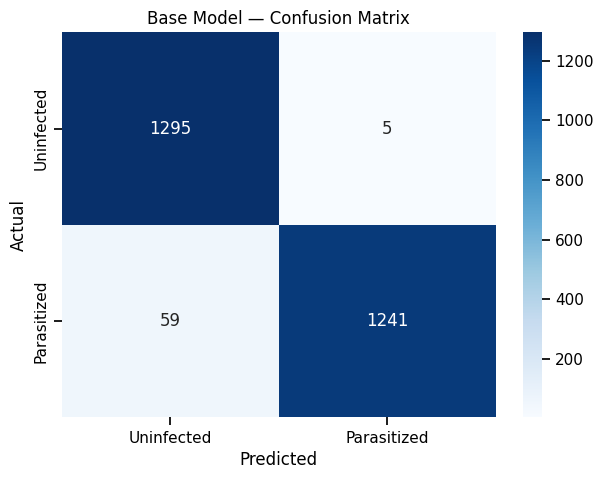

In [28]:
base_report = evaluate_and_plot_confusion_matrix(
    model, test_images, test_labels, model_name='Base Model'
)


<b>Plotting the train and validation curves

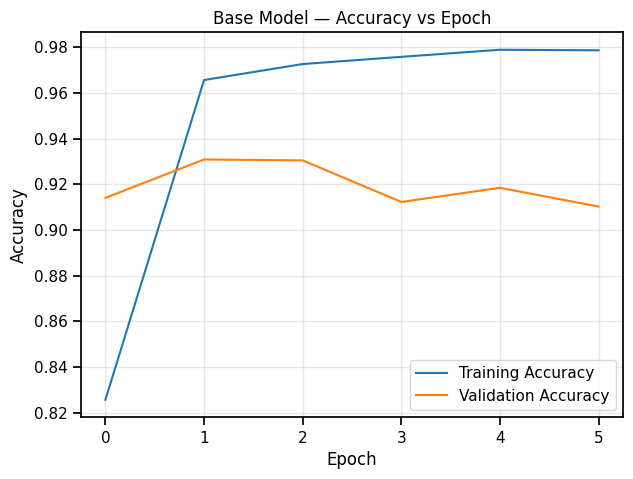

In [29]:
plot_accuracy(history, title='Base Model — Accuracy vs Epoch')


Next, we build a stronger CNN by increasing the model capacity. The goal is to see whether a deeper and wider architecture improves performance over the base model.


###<b> Model 1
####<b> Trying to improve the performance of our model by adding new layers


In [30]:
# Clear the backend so Model 1 starts from a fresh graph.
backend.clear_session()
reset_seeds(SEED)


###<b> Building the Model

In [31]:
# ============================================================
# MODEL 1: DEEPER CNN WITH WIDENING FILTERS
# ============================================================
# This model increases the number of filters as the network gets deeper.
# Earlier layers learn simpler patterns; later layers learn richer, more abstract features.

model1 = Sequential()

# Block 1
model1.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(64, 64, 3)))
model1.add(MaxPooling2D((2, 2)))
model1.add(Dropout(0.2))

# Block 2
model1.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model1.add(MaxPooling2D((2, 2)))
model1.add(Dropout(0.2))

# Block 3
model1.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model1.add(MaxPooling2D((2, 2)))
model1.add(Dropout(0.3))

# Block 4
model1.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
model1.add(MaxPooling2D((2, 2)))
model1.add(Dropout(0.3))

# The dense head combines learned image features into the final class prediction.
model1.add(Flatten())
model1.add(Dense(512, activation='relu'))
model1.add(Dropout(0.5))
model1.add(Dense(2, activation='softmax'))

model1.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,180,290 (4.50 MB)

 Trainable params: 1,180,290 (4.50 MB)

 Non-trainable params: 0 (0.00 B)

###<b> Compiling the model

In [32]:
model1.compile(
    loss='categorical_crossentropy',
    optimizer=optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)


<b> Using Callbacks

In [33]:
callbacks = make_callbacks('model1_deeper_cnn', patience=3)


<b>Fit and Train the model

In [34]:
history1 = model1.fit(train_images, train_labels,
                      batch_size=32,
                      callbacks=callbacks,
                      validation_split=0.2,
                      epochs=20,
                      verbose=1)

Epoch 1/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - accuracy: 0.8162 - loss: 0.3698 - val_accuracy: 0.9265 - val_loss: 0.2553
Epoch 2/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9744 - loss: 0.0855 - val_accuracy: 0.9589 - val_loss: 0.1222
Epoch 3/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9791 - loss: 0.0698 - val_accuracy: 0.9431 - val_loss: 0.1816
Epoch 4/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9791 - loss: 0.0648 - val_accuracy: 0.9559 - val_loss: 0.1318
Epoch 5/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9790 - loss: 0.0670 - val_accuracy: 0.9513 - val_loss: 0.1536
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


###<b> Evaluating the model

In [35]:
model1_loss, model1_accuracy = model1.evaluate(test_images, test_labels, verbose=0)
print('Model 1 Test Accuracy:', round(model1_accuracy, 4))


Model 1 Test Accuracy: 0.9785


<b> Plotting the confusion matrix

              precision    recall  f1-score   support

  Uninfected     0.9684    0.9892    0.9787      1300
 Parasitized     0.9890    0.9677    0.9782      1300

    accuracy                         0.9785      2600
   macro avg     0.9787    0.9785    0.9785      2600
weighted avg     0.9787    0.9785    0.9785      2600



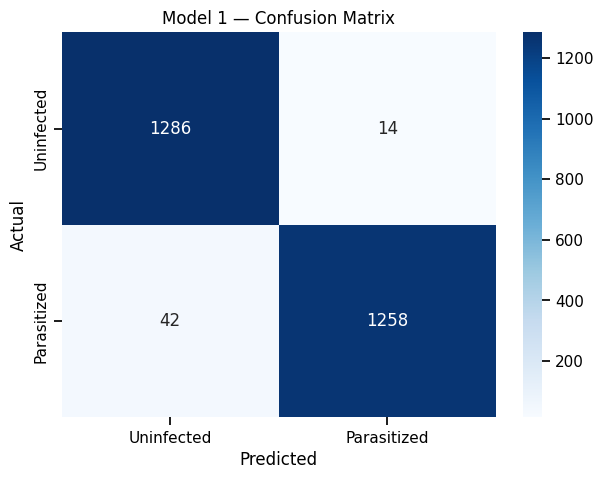

In [36]:
model1_report = evaluate_and_plot_confusion_matrix(
    model1, test_images, test_labels, model_name='Model 1'
)


<b> Plotting the train and the validation curves

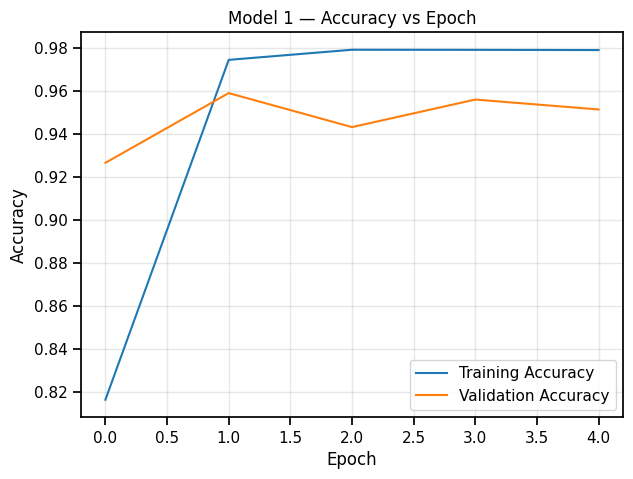

In [37]:
plot_accuracy(history1, title='Model 1 — Accuracy vs Epoch')

### <b>Think about it:</b>

Model 1 tests whether adding more feature-learning capacity improves performance. If training accuracy improves but validation accuracy does not, the model may be overfitting. If both improve, the added capacity is useful.


###<b> Model 2 with Batch Normalization

In [38]:
backend.clear_session()
reset_seeds(SEED)


###<b> Building the Model

In [39]:
# ============================================================
# MODEL 2: BATCH NORMALIZATION + LEAKYRELU
# ============================================================
# This model tests whether more stable training improves classification.
# Batch normalization stabilizes activations, while LeakyReLU keeps gradients flowing.

model2 = Sequential()

model2.add(Conv2D(32, (3, 3), input_shape=(64, 64, 3), padding='same'))
model2.add(BatchNormalization())
model2.add(LeakyReLU(negative_slope=0.1))
model2.add(MaxPooling2D((2, 2)))

model2.add(Conv2D(64, (3, 3), padding='same'))
model2.add(BatchNormalization())
model2.add(LeakyReLU(negative_slope=0.1))
model2.add(MaxPooling2D((2, 2)))

model2.add(Conv2D(64, (3, 3), padding='same'))
model2.add(BatchNormalization())
model2.add(LeakyReLU(negative_slope=0.1))
model2.add(MaxPooling2D((2, 2)))

model2.add(Flatten())
model2.add(Dense(512))
model2.add(BatchNormalization())
model2.add(LeakyReLU(negative_slope=0.1))
model2.add(Dropout(0.4))
model2.add(Dense(2, activation='softmax'))

# Keep the optimizer explicit so the learning rate can be tuned easily.
adam = optimizers.Adam(learning_rate=0.001)

model2.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,157,698 (8.23 MB)

 Trainable params: 2,156,354 (8.23 MB)

 Non-trainable params: 1,344 (5.25 KB)

###<b>Compiling the model

In [40]:
model2.compile(
    loss='categorical_crossentropy',
    optimizer=optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)


<b> Using callbacks

In [41]:
callbacks = make_callbacks('model2_bn_leakyrelu', patience=3)


<b>Fit and train the model

In [42]:
history2 = model2.fit(train_images, train_labels,
                      batch_size=32,
                      callbacks=callbacks,
                      validation_split=0.2,
                      epochs=20,
                      verbose=1)

Epoch 1/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.9203 - loss: 0.2170 - val_accuracy: 0.8638 - val_loss: 0.4164
Epoch 2/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9759 - loss: 0.0769 - val_accuracy: 0.9179 - val_loss: 0.2462
Epoch 3/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9793 - loss: 0.0663 - val_accuracy: 0.9285 - val_loss: 0.2105
Epoch 4/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9826 - loss: 0.0569 - val_accuracy: 0.8814 - val_loss: 0.4650
Epoch 5/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9845 - loss: 0.0492 - val_accuracy: 0.8710 - val_loss: 0.5239
Epoch 6/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9853 - loss: 0.0457 - val_accuracy: 0.8830 - val_loss: 0.5293
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.


<b>Plotting the train and validation accuracy

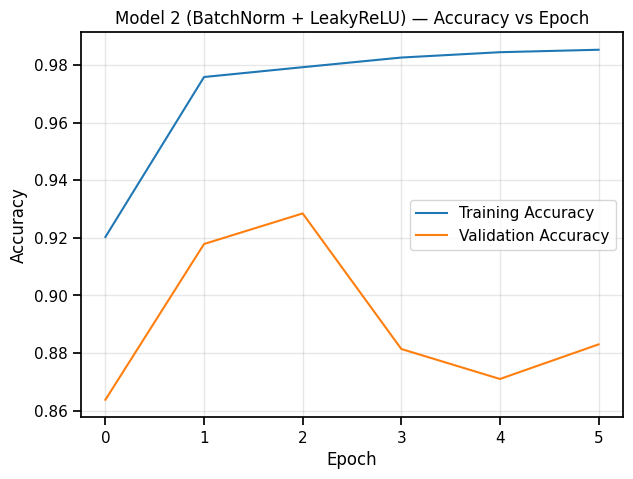

In [43]:
plot_accuracy(history2, title='Model 2 (BatchNorm + LeakyReLU) — Accuracy vs Epoch')

###<b>Evaluating the model

In [44]:
model2_loss, model2_accuracy = model2.evaluate(test_images, test_labels, verbose=0)
print('Model 2 Test Accuracy:', round(model2_accuracy, 4))


Model 2 Test Accuracy: 0.9708


#### Observations and insights

- Batch normalization helps stabilize training by keeping activations on a more consistent scale.
- LeakyReLU allows a small gradient to pass through even for negative inputs, which can make training more reliable.
- For this medical-screening task, the key question is whether this model improves **parasitized recall**, because that reflects how well it catches infected cells.


<b> Generate the classification report and confusion matrix

              precision    recall  f1-score   support

  Uninfected     0.9480    0.9962    0.9715      1300
 Parasitized     0.9959    0.9454    0.9700      1300

    accuracy                         0.9708      2600
   macro avg     0.9720    0.9708    0.9708      2600
weighted avg     0.9720    0.9708    0.9708      2600



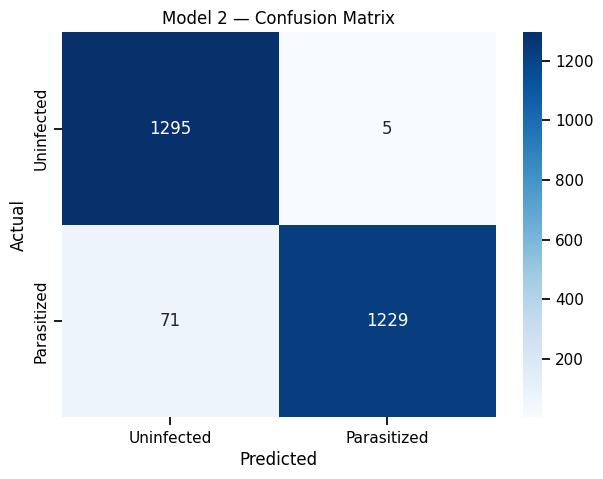

In [45]:
model2_report = evaluate_and_plot_confusion_matrix(
    model2, test_images, test_labels, model_name='Model 2'
)


### <b>Think About It:</b>

Model 2 tests whether training stability improves performance. Batch normalization and LeakyReLU may help the model learn more smoothly, but the final value depends on test-set metrics, not training accuracy alone.


###<b>Model 3 with Data Augmentation

In [46]:
backend.clear_session()
reset_seeds(SEED)


###<b> Use image data generator

In [47]:
# ============================================================
# DATA AUGMENTATION SETUP
# ============================================================
# This block creates a manual train-validation split and applies mild image augmentation.
# The transformations preserve the class label while adding realistic spatial variation.

X_train, X_val, y_train, y_val = train_test_split(
    train_images,
    train_labels,
    test_size=0.2,
    random_state=SEED,
    stratify=train_labels_int
)

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_generator = datagen.flow(X_train, y_train, batch_size=32, seed=SEED)
val_generator = ImageDataGenerator().flow(X_val, y_val, batch_size=32, shuffle=False)


### <b>Think About It:</b>

Data augmentation creates realistic variations of the training images. This can reduce overfitting by helping the model learn patterns that are stable across rotation, shifts, and zoom.


####<B>Visualizing Augmented images

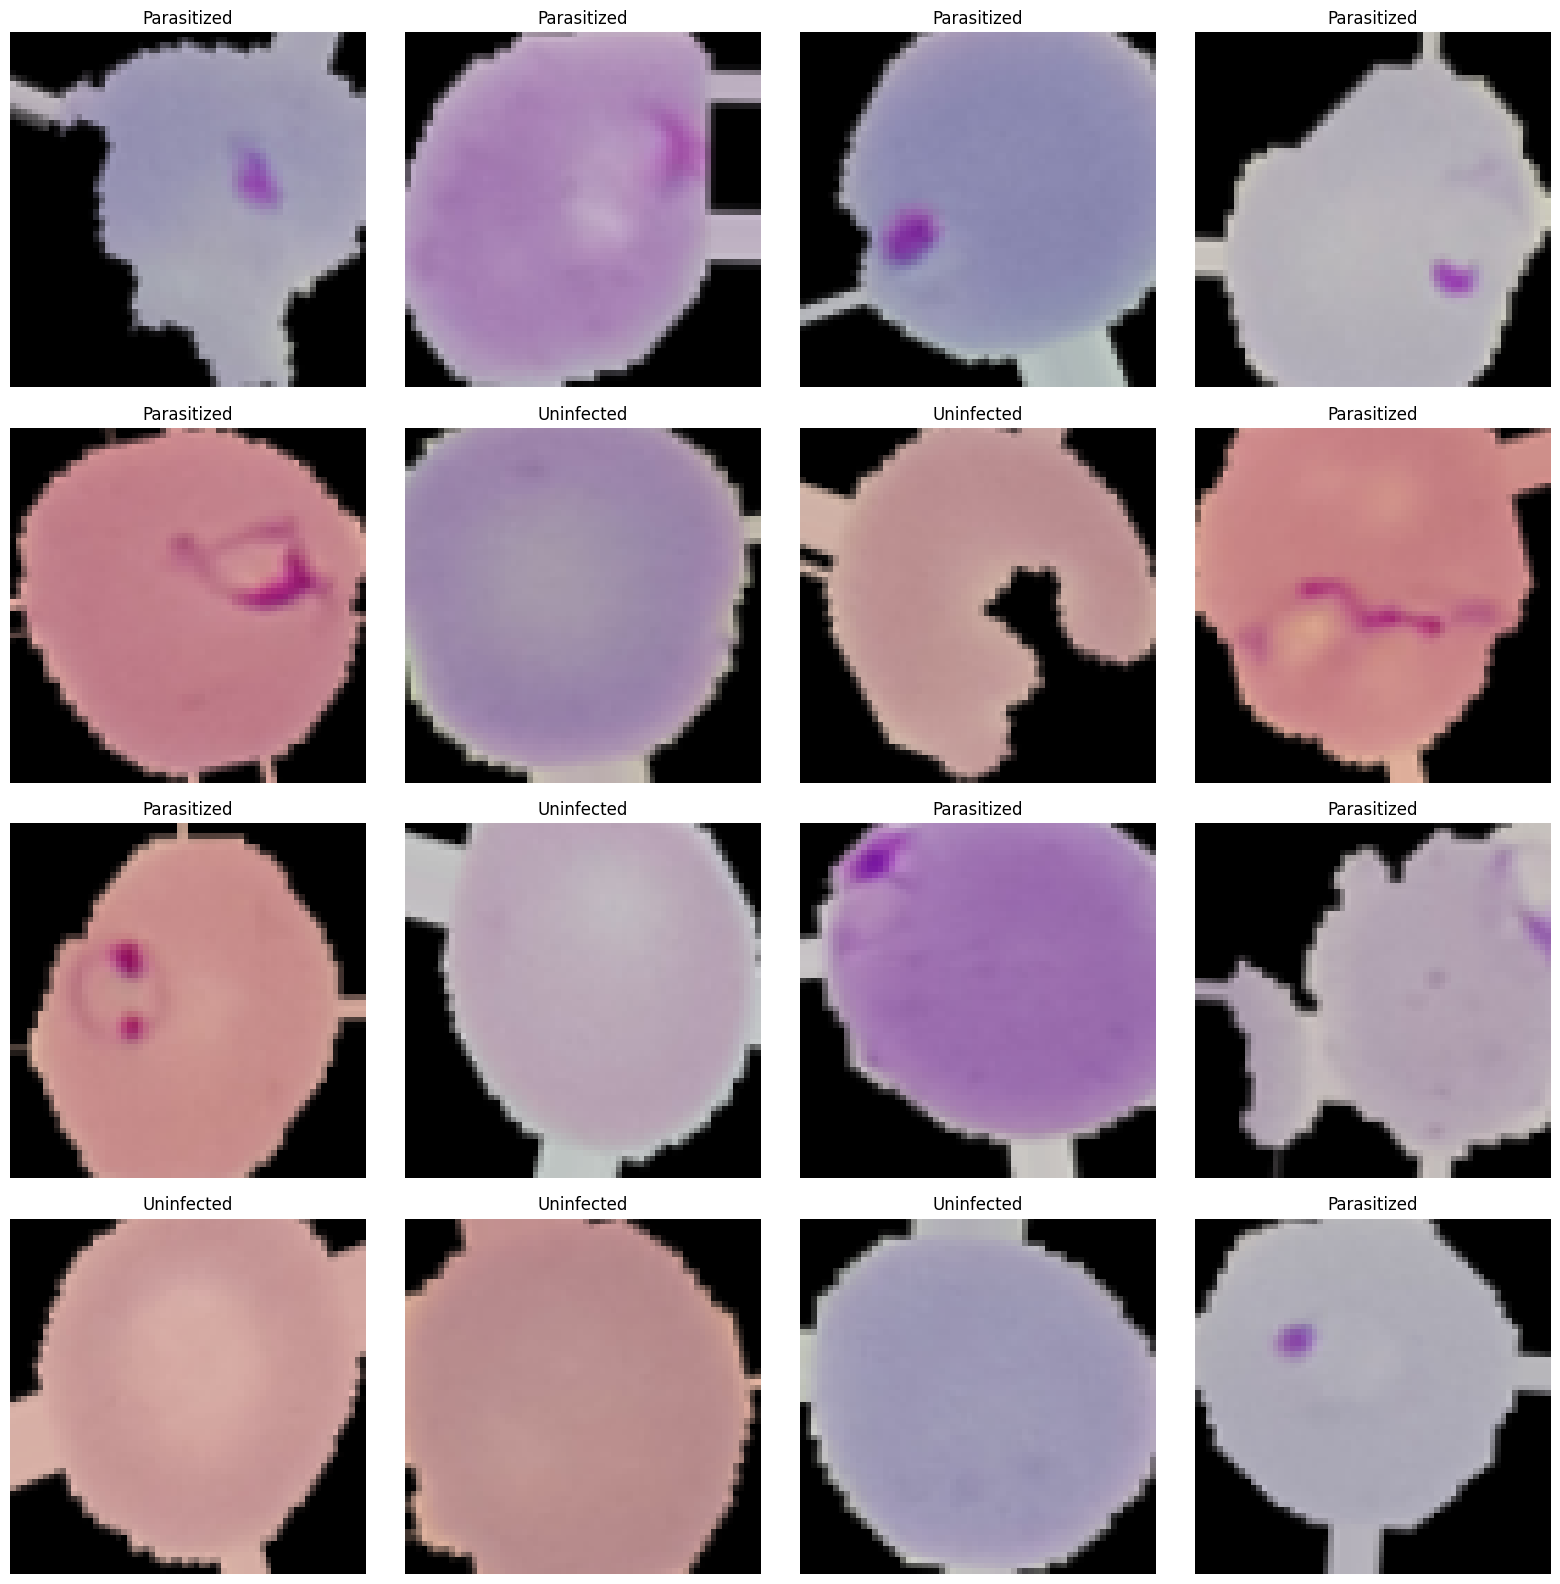

In [48]:
# Visualize one batch of augmented images to confirm the transformations look reasonable.

images, labels = next(train_generator)

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
for (image, label, ax) in zip(images, labels, axes.flatten()):
    ax.imshow(image)
    ax.set_title('Parasitized' if label[1] == 1 else 'Uninfected')
    ax.axis('off')

plt.tight_layout()
plt.show()


#### Observations and insights

- The augmented images show realistic rotations, shifts, zooms, and flips.
- These changes do not alter the biological label of the cell.
- Augmentation should help the model focus on general cell features instead of memorizing exact image positions or orientations.


###<b>Building the Model

In [49]:
# ============================================================
# MODEL 3: MODEL 2 ARCHITECTURE WITH AUGMENTED DATA
# ============================================================
# This model keeps the architecture similar to Model 2 and changes the training data pipeline.
# This helps isolate the effect of augmentation.

model3 = Sequential()

model3.add(Conv2D(32, (3, 3), input_shape=(64, 64, 3), padding='same'))
model3.add(BatchNormalization())
model3.add(LeakyReLU(negative_slope=0.1))
model3.add(MaxPooling2D((2, 2)))

model3.add(Conv2D(64, (3, 3), padding='same'))
model3.add(BatchNormalization())
model3.add(LeakyReLU(negative_slope=0.1))
model3.add(MaxPooling2D((2, 2)))

model3.add(Conv2D(64, (3, 3), padding='same'))
model3.add(BatchNormalization())
model3.add(LeakyReLU(negative_slope=0.1))
model3.add(MaxPooling2D((2, 2)))

model3.add(Flatten())
model3.add(Dense(512))
model3.add(BatchNormalization())
model3.add(LeakyReLU(negative_slope=0.1))
model3.add(Dropout(0.4))
model3.add(Dense(2, activation='softmax'))

adam = optimizers.Adam(learning_rate=0.001)
model3.compile(loss='categorical_crossentropy', optimizer=adam, metrics=['accuracy'])
model3.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,157,698 (8.23 MB)

 Trainable params: 2,156,354 (8.23 MB)

 Non-trainable params: 1,344 (5.25 KB)

<b>Using Callbacks

In [50]:
callbacks = make_callbacks('model3_augmented', patience=3)


<b> Fit and Train the model

In [51]:
# Fit Model 3 using the augmented training generator and the validation generator.

history3 = model3.fit(train_generator,
                      validation_data=val_generator,
                      callbacks=callbacks,
                      epochs=20,
                      verbose=1)


Epoch 1/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 39s 52ms/step - accuracy: 0.9124 - loss: 0.2437 - val_accuracy: 0.9521 - val_loss: 0.2309
Epoch 2/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 30s 49ms/step - accuracy: 0.9628 - loss: 0.1142 - val_accuracy: 0.9760 - val_loss: 0.0660
Epoch 3/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 29s 47ms/step - accuracy: 0.9652 - loss: 0.1074 - val_accuracy: 0.9744 - val_loss: 0.0769
Epoch 4/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 29s 47ms/step - accuracy: 0.9679 - loss: 0.0990 - val_accuracy: 0.9581 - val_loss: 0.1118
Epoch 5/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 30s 47ms/step - accuracy: 0.9673 - loss: 0.1015 - val_accuracy: 0.9708 - val_loss: 0.0761
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


###<B>Evaluating the model

<b>Plot the train and validation accuracy

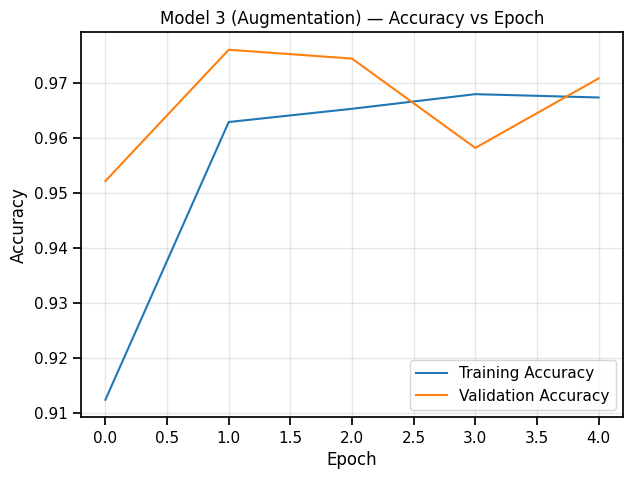

Model 3 Test Accuracy: 0.9792


In [52]:
plot_accuracy(history3, title='Model 3 (Augmentation) — Accuracy vs Epoch')

model3_loss, model3_accuracy = model3.evaluate(test_images, test_labels, verbose=0)
print('Model 3 Test Accuracy:', round(model3_accuracy, 4))


<B>Plotting the classification report and confusion matrix

              precision    recall  f1-score   support

  Uninfected     0.9778    0.9808    0.9793      1300
 Parasitized     0.9807    0.9777    0.9792      1300

    accuracy                         0.9792      2600
   macro avg     0.9792    0.9792    0.9792      2600
weighted avg     0.9792    0.9792    0.9792      2600



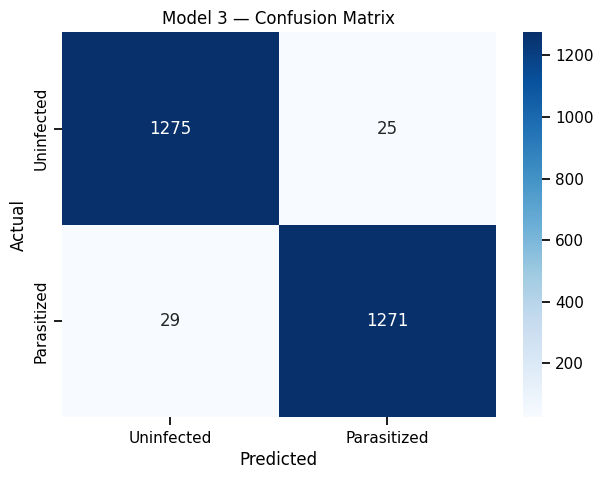

In [53]:
model3_report = evaluate_and_plot_confusion_matrix(
    model3, test_images, test_labels, model_name='Model 3'
)


Next, we test a pretrained model. VGG16 was originally trained on natural images, so this step evaluates whether general image features can transfer to malaria cell images.


### **Pre-trained model (VGG16)**
- Import VGG16 network upto any layer you choose
- Add Fully Connected Layers on top of it

In [54]:
# ============================================================
# MODEL 4: VGG16 TRANSFER LEARNING
# ============================================================
# This block uses VGG16 as a fixed feature extractor.
# VGG16 requires ImageNet preprocessing, so separate test/train arrays are created for this model.

backend.clear_session()
reset_seeds(SEED)

train_images_vgg = preprocess_input((train_images * 255).astype('float32'))
test_images_vgg = preprocess_input((test_images * 255).astype('float32'))

# Load the pretrained convolutional base and remove the original ImageNet classifier.
vgg = VGG16(include_top=False, weights='imagenet', input_shape=(64, 64, 3))
vgg.trainable = False

x = Flatten()(vgg.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
pred = Dense(2, activation='softmax')(x)

model4 = Model(vgg.input, pred)
model4.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 15,272,898 (58.26 MB)

 Trainable params: 557,954 (2.13 MB)

 Non-trainable params: 14,714,944 (56.13 MB)

###<b>Compiling the model

In [55]:
# Compile the transfer-learning model with a smaller learning rate.
model4.compile(
    loss='categorical_crossentropy',
    optimizer=optimizers.Adam(learning_rate=0.0001),
    metrics=['accuracy']
)


<b> using callbacks

In [56]:
callbacks = make_callbacks('model4_vgg16_transfer', patience=3)


<b>Fit and Train the model

In [57]:
history4 = model4.fit(
    train_images_vgg,
    train_labels,
    epochs=10,
    callbacks=callbacks,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


Epoch 1/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 28s 35ms/step - accuracy: 0.8950 - loss: 0.2609 - val_accuracy: 0.8944 - val_loss: 0.2546
Epoch 2/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.9464 - loss: 0.1529 - val_accuracy: 0.9010 - val_loss: 0.2511
Epoch 3/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.9526 - loss: 0.1311 - val_accuracy: 0.9022 - val_loss: 0.2529
Epoch 4/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.9595 - loss: 0.1145 - val_accuracy: 0.9022 - val_loss: 0.2642
Epoch 5/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.9642 - loss: 0.1026 - val_accuracy: 0.9069 - val_loss: 0.2448
Epoch 6/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.9682 - loss: 0.0924 - val_accuracy: 0.9020 - val_loss: 0.2688
Epoch 7/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.9719 - loss: 0.0827 - val_accuracy: 0.9020 - val_loss: 0.2815
Epoch 8/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.9753 - loss: 0.0732 - 

<b>Plot the train and validation accuracy

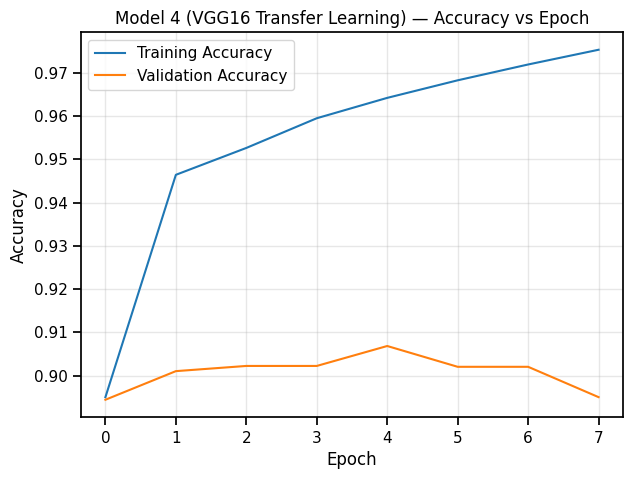

In [58]:
plot_accuracy(history4, title='Model 4 (VGG16 Transfer Learning) — Accuracy vs Epoch')

### Observations and insights

- VGG16 uses pretrained ImageNet features, which may capture general patterns such as edges, contrast, and texture.
- However, microscopy images are very different from natural images, so transfer learning may not always outperform custom CNNs.
- In this notebook, VGG16 is used as a feature extractor by freezing the convolutional base and training a small classifier on top.

- This result suggests that transfer learning is not automatically superior; pretrained features are most useful when the original training images are similar to the new task, and ImageNet images are very different from stained blood-smear microscopy images.


###<b> Evaluating the model

In [59]:
model4_loss, model4_accuracy = model4.evaluate(test_images_vgg, test_labels, verbose=0)
print('VGG16 Test Accuracy:', round(model4_accuracy, 4))


VGG16 Test Accuracy: 0.9415


<b>Plotting the classification report and confusion matrix

              precision    recall  f1-score   support

  Uninfected     0.9100    0.9800    0.9437      1300
 Parasitized     0.9783    0.9031    0.9392      1300

    accuracy                         0.9415      2600
   macro avg     0.9442    0.9415    0.9415      2600
weighted avg     0.9442    0.9415    0.9415      2600



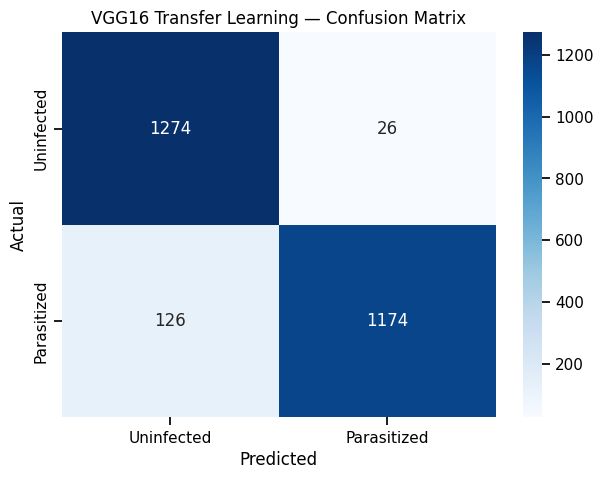

In [60]:
model4_report = evaluate_and_plot_confusion_matrix(
    model4, test_images_vgg, test_labels, model_name='VGG16 Transfer Learning'
)


### <b>Think about it:</b>

Transfer learning can be useful when pretrained features match the new task. If VGG16 underperforms here, it may be because ImageNet features are not fully suited to microscopic blood-cell images.


## **Model Comparison and Final Solution**
All five models were trained and evaluated on the same held-out test set. Conceptually, the models test different ideas:

- **Base CNN**: provides a simple benchmark.
- **Model 1: Deeper CNN**: increases feature-learning capacity.
- **Model 2: BatchNorm + LeakyReLU**: improves training stability and gradient flow.
- **Model 3: Data Augmentation**: tests whether realistic image variation improves generalization.
- **Model 4: VGG16 Transfer Learning**: tests whether pretrained natural-image features transfer to microscopy.

The final model should be chosen based on the metric that best matches the goal of the project. For malaria screening, the priority is to reduce missed infections. Because a missed infection is the costliest error in a screening setting, the headline metric is **recall on the parasitized class**.

The cells below build a comparison table, plot the metrics side by side, and select the recommended model using a screening-priority ranking (parasitized recall first, then parasitized F1, then weighted F1, then test accuracy).

In [61]:
# Build a comparison table by evaluating each trained model on the same test set.

def evaluate_model_for_comparison(model_object, model_name, X_test_data, y_test_data):
    """Evaluate a trained model and return a dict of headline classification metrics."""
    # Convert one-hot labels back to integers if needed.
    if len(y_test_data.shape) > 1:
        y_true = np.argmax(y_test_data, axis=1)
    else:
        y_true = y_test_data

    # Get predicted probabilities and convert to class labels.
    y_pred_prob = model_object.predict(X_test_data, verbose=0)
    if y_pred_prob.shape[-1] == 1:
        y_pred = (y_pred_prob > 0.5).astype('int32').flatten()
    else:
        y_pred = np.argmax(y_pred_prob, axis=1)

    report = classification_report(
        y_true, y_pred,
        target_names=['Uninfected', 'Parasitized'],
        output_dict=True,
    )

    return {
        'Model':                 model_name,
        'Test Accuracy':         accuracy_score(y_true, y_pred),
        'Uninfected Precision':  report['Uninfected']['precision'],
        'Uninfected Recall':     report['Uninfected']['recall'],
        'Uninfected F1':         report['Uninfected']['f1-score'],
        'Parasitized Precision': report['Parasitized']['precision'],
        'Parasitized Recall':    report['Parasitized']['recall'],
        'Parasitized F1':        report['Parasitized']['f1-score'],
        'Weighted F1':           report['weighted avg']['f1-score'],
    }


# Evaluate the models in the order they were built.
comparison_results = [
    evaluate_model_for_comparison(model,  'Base CNN',                         test_images,     test_labels),
    evaluate_model_for_comparison(model1, 'Model 1: Deeper CNN',              test_images,     test_labels),
    evaluate_model_for_comparison(model2, 'Model 2: BatchNorm + LeakyReLU',   test_images,     test_labels),
    evaluate_model_for_comparison(model3, 'Model 3: Data Augmentation',       test_images,     test_labels),
    evaluate_model_for_comparison(model4, 'Model 4: VGG16 Transfer Learning', test_images_vgg, test_labels),
]

comparison_df = pd.DataFrame(comparison_results)
comparison_df.round(4)


,Model,Test Accuracy,Uninfected Precision,Uninfected Recall,Uninfected F1,Parasitized Precision,Parasitized Recall,Parasitized F1,Weighted F1
0,Base CNN,0.9754,0.9564,0.9962,0.9759,0.9960,0.9546,0.9749,0.9754
1,Model 1: Deeper CNN,0.9785,0.9684,0.9892,0.9787,0.9890,0.9677,0.9782,0.9785
2,Model 2: BatchNorm + LeakyReLU,0.9708,0.9480,0.9962,0.9715,0.9959,0.9454,0.9700,0.9708
3,Model 3: Data Augmentation,0.9792,0.9778,0.9808,0.9793,0.9807,0.9777,0.9792,0.9792
4,Model 4: VGG16 Transfer Learning,0.9415,0.9100,0.9800,0.9437,0.9783,0.9031,0.9392,0.9415


In [62]:
# Show a focused view of the metrics most relevant to a screening decision.
comparison_df[[
    'Model',
    'Test Accuracy',
    'Parasitized Recall',
    'Parasitized F1',
    'Weighted F1',
]].round(4)


,Model,Test Accuracy,Parasitized Recall,Parasitized F1,Weighted F1
0,Base CNN,0.9754,0.9546,0.9749,0.9754
1,Model 1: Deeper CNN,0.9785,0.9677,0.9782,0.9785
2,Model 2: BatchNorm + LeakyReLU,0.9708,0.9454,0.9700,0.9708
3,Model 3: Data Augmentation,0.9792,0.9777,0.9792,0.9792
4,Model 4: VGG16 Transfer Learning,0.9415,0.9031,0.9392,0.9415


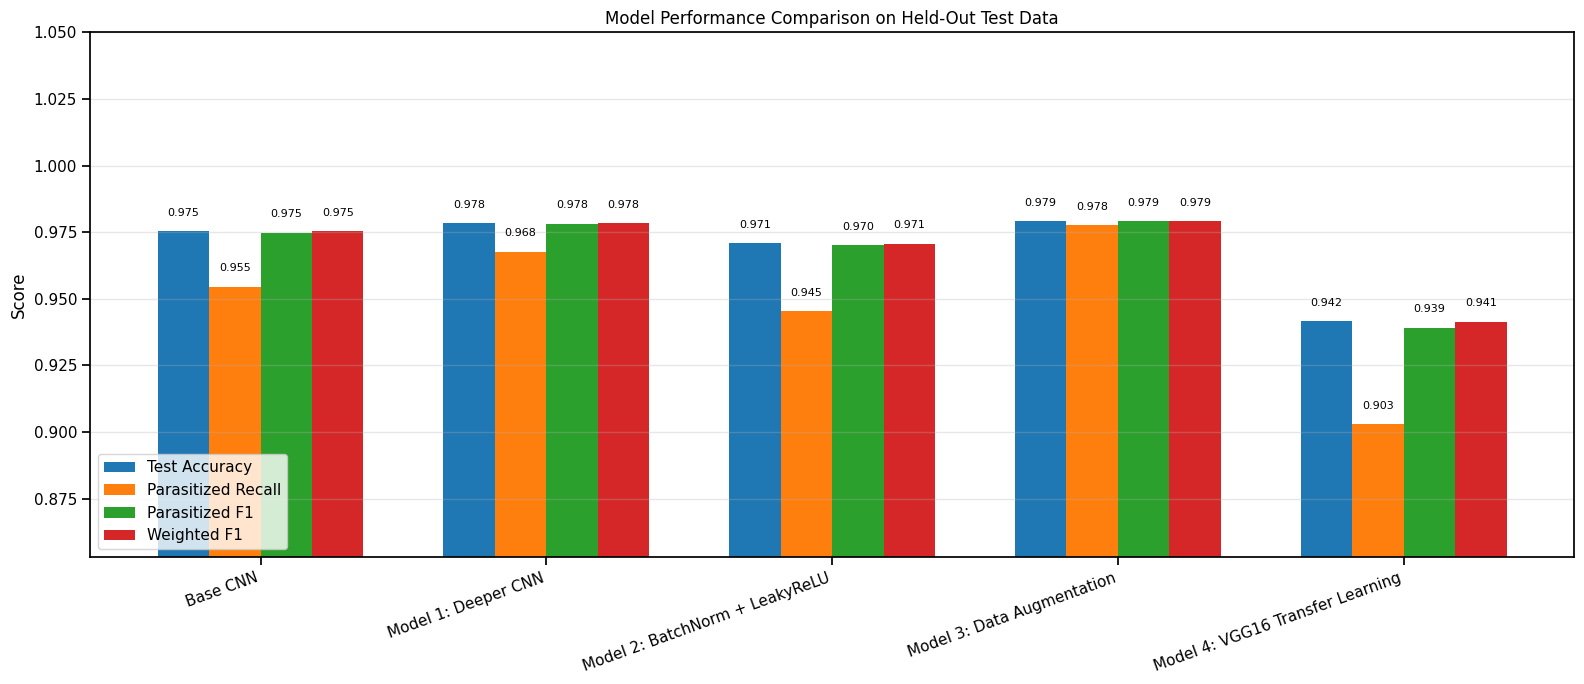

In [63]:
# Plot the four key metrics side by side, in the order the models were built.
metrics_to_plot = ['Test Accuracy', 'Parasitized Recall', 'Parasitized F1', 'Weighted F1']

models = comparison_df['Model']
x = np.arange(len(models))
width = 0.18

plt.figure(figsize=(16, 7))

for i, metric in enumerate(metrics_to_plot):
    bars = plt.bar(x + (i - 1.5) * width, comparison_df[metric], width, label=metric)
    for bar in bars:
        score = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            score + 0.005,
            f'{score:.3f}',
            ha='center', va='bottom', fontsize=8,
        )

plt.xticks(x, models, rotation=20, ha='right')
plt.ylabel('Score')
plt.title('Model Performance Comparison on Held-Out Test Data')

# Auto-scale y-axis so lower-performing bars are still readable.
min_score = comparison_df[metrics_to_plot].min().min()
plt.ylim(max(0, min_score - 0.05), 1.05)

plt.legend(loc='lower left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


#### **Observations from the comparison**

* Every model is evaluated on the same held-out test set, so the rankings are directly comparable.

* The CNN models perform well because convolutional layers are designed to learn local visual patterns, such as edges, textures, color changes, and small structures inside cells. This makes CNNs well suited for microscopy-image classification.

* The custom CNNs — Base CNN, Model 1, Model 2, and Model 3 — all reach high accuracy, suggesting that they can learn useful image patterns such as differences in cell texture, stain intensity, and small parasite-like features inside the cells.

* In this notebook, data augmentation produced the strongest screening-priority model. This suggests that realistic transformations helped the model generalize to unseen test images.

* VGG16 did not perform as well as the custom CNNs. This may be because VGG16 was originally trained on everyday images, not microscopic cell images. This shows that transfer learning is not automatically better when the source image domain is very different from the target task.

* The model with the highest parasitized recall is not always the same as the model with the highest overall accuracy. If the model with the highest accuracy is different from the screening-priority model, that is not a contradiction. It simply means the models are being judged by different definitions of "best."

* More complex models do not always perform better. For this dataset, simpler custom CNNs may be strong enough to capture the key visual patterns.

* The per-model confusion matrices and classification reports plotted earlier in the notebook show class-level precision and recall for each model. The summary table here aggregates those metrics into a single side-by-side view for easier comparison.


### **Proposal for the final solution design**

The final model is selected using a **screening-priority ranking**: **parasitized recall first**, followed by **parasitized F1**, **weighted F1**, and **test accuracy** as tie-breakers.

This ordering reflects the clinical reality of malaria screening: a missed infection carries greater consequences than a false alarm. Therefore, the main decision metric should be the one that directly measures how well the model avoids missing infected cells.



In [64]:
# Rank models by screening priority and print the recommended one.
# Priority: Parasitized Recall first (catch infections), then Parasitized F1
# (balance recall against precision), then Weighted F1, then Test Accuracy.
ranking_df = comparison_df.sort_values(
    by=['Parasitized Recall', 'Parasitized F1', 'Weighted F1', 'Test Accuracy'],
    ascending=False,
).reset_index(drop=True)

best_model = ranking_df.iloc[0]

print('=' * 60)
print('Recommended model based on screening priority:')
print('=' * 60)
print(f"Model:              {best_model['Model']}")
print(f"Parasitized Recall: {best_model['Parasitized Recall']:.4f}")
print(f"Parasitized F1:     {best_model['Parasitized F1']:.4f}")
print(f"Weighted F1:        {best_model['Weighted F1']:.4f}")
print(f"Test Accuracy:      {best_model['Test Accuracy']:.4f}")
print('=' * 60)

# Also print the best model by overall test accuracy, in case it differs from
# the screening-priority pick — useful for interpreting the trade-off.
best_by_acc = comparison_df.sort_values('Test Accuracy', ascending=False).iloc[0]
if best_by_acc['Model'] != best_model['Model']:
    print('\nBest model by overall test accuracy alone:')
    print(f"  {best_by_acc['Model']} (accuracy = {best_by_acc['Test Accuracy']:.4f})")
    print('Different from the screening-priority pick — reflects the trade-off')
    print('between catching infections and overall correctness.')


Recommended model based on screening priority:
Model:              Model 3: Data Augmentation
Parasitized Recall: 0.9777
Parasitized F1:     0.9792
Weighted F1:        0.9792
Test Accuracy:      0.9792


##**Final Choice**: Model 3 (Data Augmentation)


### **Why this model is recommended**

* **The headline metric matches the medical goal.**
  Recall on the parasitized class measures the fraction of truly infected cells the model successfully detects. **Model 3: Data Augmentation** achieved a **parasitized recall of 0.9777**, meaning it correctly identified about **97.8% of infected cells**. In a screening context, this is the most important failure mode: a parasitized cell wrongly classified as uninfected could represent a missed infection.

* **The supporting metrics prevent over-prediction.**
  A model could achieve very high parasitized recall by simply predicting every cell as parasitized. Model 3 also achieved a **parasitized F1 score of 0.9792** and a **weighted F1 score of 0.9792**, showing that it maintained strong balance while detecting infected cells. These scores suggest that the model is not simply over-flagging cells as parasitized, but is performing well across both classes.

* **The model performs strongly overall and is ready for later use.**
  Model 3 achieved a **test accuracy of 0.9792**, meaning it correctly classified about **97.9% of held-out test images**. The best model weights are saved during training using `ModelCheckpoint`, so the selected model can be reloaded for prediction without needing to retrain it.



**Potential improvements**

Model 3 could be improved further by tuning the strength of data augmentation and testing additional biologically reasonable transformations, such as mild brightness and contrast changes to account for staining variation. Care should be taken to avoid aggressive transformations that may distort or remove small parasite-like features. The model could also be trained with learning-rate scheduling, longer training with early stopping, or additional regularization. For the transfer-learning model, later VGG16 layers could be selectively unfrozen and fine-tuned to better adapt pretrained features to microscopy images. Future model selection should continue to prioritize parasitized recall and parasitized F1, since these metrics best reflect the goal of reducing missed infections.


---
## **Final Submission Report**

### Executive Summary | Problem & Solution Summary | Recommendations for Implementation

### **Executive Summary**

#### Key Takeaways

This project addresses one of global health's most persistent diagnostic challenges: accurate, scalable detection of malaria-infected red blood cells from microscopy images. Using a dataset of 64×64-pixel RGB cell images labeled as either parasitized or uninfected, five convolutional neural network (CNN) architectures were trained, tuned, and evaluated against a held-out test set.

The headline findings are as follows:

- The dataset is well-balanced, with approximately equal numbers of parasitized and uninfected cells across both training and test splits, making accuracy a valid — though not sufficient — metric.
- Five models were built and compared: a Base CNN, a Deeper CNN (Model 1), a CNN with Batch Normalization and LeakyReLU (Model 2), the same architecture trained with data augmentation (Model 3), and VGG16 transfer learning (Model 4).
- **Model 3 (Data Augmentation) was selected as the final recommended model.** It achieved a parasitized recall of **0.9777**, a parasitized F1 score of **0.9792**, a weighted F1 score of **0.9792**, and an overall test accuracy of **97.92%**.
- Data augmentation — including rotations, shifts, zooms, and horizontal flips — emerged as the single most impactful design choice. It enabled the model to generalize across staining variation, image orientation, and cell position without seeing those variations in training.
- VGG16 transfer learning did not outperform custom CNNs trained from scratch, confirming that pretrained natural-image features do not automatically transfer to microscopy data.
- The primary evaluation metric is **parasitized recall**, because in a clinical screening context, a missed infection is more dangerous than a false alarm. Model 3 correctly identified approximately 97.8% of infected cells in the held-out test set.

#### Final Proposed Model Specifications

| Attribute | Value |
|---|---|
| Model Name | Model 3 — CNN with Data Augmentation |
| Architecture | 3-block CNN (Conv2D + BatchNorm + LeakyReLU + MaxPool), Flatten, Dense(512), Dropout(0.4), Softmax(2) |
| Input Shape | 64 × 64 × 3 (RGB) |
| Augmentation | Rotation ±20°, Width/Height shift 10%, Zoom 10%, Horizontal flip |
| Optimizer | Adam (α = 0.001) |
| Loss Function | Categorical Cross-Entropy |
| Batch Size | 32 |
| Callbacks | EarlyStopping (patience=3), ModelCheckpoint (best val_loss) |
| **Parasitized Recall** | **0.9777** |
| **Parasitized F1** | **0.9792** |
| **Weighted F1** | **0.9792** |
| **Test Accuracy** | **97.92%** |

#### Key Next Steps

- Tune augmentation parameters — extend brightness and contrast variation to account for lab-to-lab staining differences.
- Implement learning rate scheduling (e.g., `ReduceLROnPlateau`) to refine convergence during training.
- Fine-tune VGG16 by selectively unfreezing the final convolutional blocks and retraining on microscopy data.
- Validate the model on an external malaria dataset to confirm generalization across imaging conditions.
- Package the model as a deployable API (FastAPI or Flask) with a lightweight front-end for field use.
- Engage clinical collaborators in Bangladesh and other high-burden regions to assess workflow integration.

---
### **Problem and Solution Summary**

#### What Problem Was Being Solved?

Malaria remains a leading cause of preventable death globally, particularly in sub-Saharan Africa and South Asia. Accurate diagnosis traditionally requires trained laboratory technicians to manually inspect Giemsa-stained blood smear slides under a microscope — a process that is slow, expensive, and dependent on human expertise. In settings where expert microscopists are unavailable, incorrect or delayed diagnoses lead directly to preventable deaths.

From a data science perspective, this is a **supervised binary image-classification problem**. Given labeled microscopy images of individual red blood cells, the model must learn to distinguish visually between parasitized cells — which exhibit darker, irregular inclusions from *Plasmodium* parasites — and uninfected cells, which appear smoother and more uniform. The clinical cost asymmetry between error types (missed infections vs. false alarms) makes **recall on the parasitized class** the primary metric of success.

#### Final Proposed Solution Design

The recommended solution is a CNN trained with data augmentation (Model 3). The architecture consists of three convolutional blocks, each comprising a Conv2D layer, Batch Normalization, a LeakyReLU activation, and a MaxPooling layer. A dense head with 512 units, dropout regularization, and a 2-unit softmax output completes the model. Key design decisions include:

- **RGB input at 64×64 pixels**, normalized to [0, 1] for stable training.
- **Batch normalization** for training stability and improved generalization.
- **LeakyReLU activations** to prevent dead neurons and maintain gradient flow.
- **Data augmentation** (rotations, shifts, zoom, horizontal flip) to expose the model to realistic image variation without acquiring additional data.
- **EarlyStopping with weight restoration** to prevent overfitting without over-training.
- Evaluation anchored to **parasitized recall** as the primary decision metric, with F1 and accuracy as supporting metrics.

#### Why Is This a Valid Solution?

Model 3 achieved **97.77% recall on the parasitized class** — meaning it correctly identified approximately 97.8% of infected cells in the held-out test set. Its F1 score of 0.9792 confirms that this high recall is not achieved by indiscriminately flagging all cells as infected; the model maintains strong precision alongside it. An overall accuracy of 97.92% further demonstrates that the solution performs reliably across both classes.

The model outperformed all other tested architectures on the primary screening metric. In particular, data augmentation produced consistent improvement over the same architecture without it, confirming that **generalization — not simply model capacity — was the limiting factor** in this task.

---
### **Recommendations for Implementation**

#### Deployment Strategy

- Package the trained model using FastAPI or Flask as a lightweight REST API endpoint that accepts cell image uploads and returns classification predictions with confidence scores.
- Build a minimal front-end interface (Streamlit or a simple web form) that field workers or laboratory technicians can use without requiring programming expertise.
- Deploy initially on a cloud instance (AWS, GCP, or Azure) with a GPU-enabled tier to ensure acceptable inference latency.
- Store model weights from `ModelCheckpoint` and version them alongside the dataset split definitions to ensure full reproducibility.

#### Key Actionables for Stakeholders

- **Clinical teams:** Define the acceptable false-negative rate threshold for the deployment context and communicate this to data science teams for threshold tuning.
- **Health IT teams:** Integrate the model API into existing laboratory information systems (LIS) or electronic health records (EHR) to minimize workflow disruption.
- **Program managers:** Establish feedback loops where laboratory technician overrides are logged and used to retrain the model periodically.
- **Policy and procurement:** Ensure sufficient mobile or edge computing capacity in low-resource field settings where internet connectivity may be limited.

#### Expected Benefits and Costs

**Benefits:**
- Reduction in missed malaria diagnoses — ~97.8% recall on parasitized cells represents a clinically significant improvement over human fatigue-related error rates.
- Faster screening throughput: model inference takes milliseconds versus minutes per manual slide review.
- Reduced dependency on specialist microscopists, enabling deployment in under-resourced settings.
- Scalability: a single deployed model can process thousands of images simultaneously with no degradation in performance.

**Estimated Costs (assumptions-based):**
- Cloud deployment infrastructure: $200–$800/month depending on traffic volume and GPU tier.
- Model retraining pipeline (quarterly): 20–40 engineering hours, primarily for data curation and validation.
- Staff training for new interface: 4–8 hours per facility, one-time.

#### Key Risks and Challenges

- **Domain shift:** The model was trained on a specific dataset; performance may degrade on images from different microscopes, staining protocols, or geographic populations.
- **Over-reliance risk:** There is a danger that clinicians may accept model output uncritically. The model should be positioned as a decision-support tool, not a replacement for clinical judgment.
- **Threshold sensitivity:** The 0.5 classification threshold may require calibration for specific deployment contexts. In high-risk settings, lowering the threshold could increase recall at the cost of more false alarms.
- **Data privacy:** Cell images may be linked to patient identifiers; strict de-identification protocols are required before model training or API deployment.
- **Regulatory pathway:** Medical AI tools in many jurisdictions require regulatory clearance (e.g., FDA 510(k) in the US, CE marking in the EU) before clinical deployment.

#### Future Improvements and Associated Analysis

- Fine-tune VGG16 by unfreezing the final convolutional blocks, which may allow pretrained features to adapt more effectively to the microscopy domain.
- Test on geographically diverse external datasets to quantify model robustness across populations and imaging equipment.
- Explore class activation mapping (CAM) or Grad-CAM to produce visual explanations that clinicians can use to verify model decisions.
- Extend the model to distinguish between *Plasmodium* species (e.g., *P. falciparum* vs. *P. vivax*), which has direct treatment implications.
- Investigate edge deployment options (TensorFlow Lite, ONNX) for offline use in field clinics with limited connectivity.